데이터 shape: (15714, 22)
컬럼 목록:
['treatment_id', 'platform', 'platform_id', 'treatment_name', 'treatment_name_len_char', 'treatment_name_len_token', 'category_large', 'category_large_id', 'category_mid', 'category_mid_id', 'category_small', 'category_small_id', 'original_price', 'selling_price', 'discount_amount', 'dis_rate', 'rating', 'rating_per_price', 'review_count', 'log_review_count', 'hospital_id', 'hospital_id_rd']
   treatment_id platform  platform_id       treatment_name  \
0          2031    yeoti            3        365 sy- 제모(여)   
1          2103    yeoti            3  365 sy- 탄력,색소,모공,홍조   
2          2187    yeoti            3            아기레이저 4만샷   

   treatment_name_len_char  treatment_name_len_token category_large  \
0                       13                         3             제모   
1                       19                         3             피부   
2                        9                         2             피부   

   category_large_id category_mid  catego

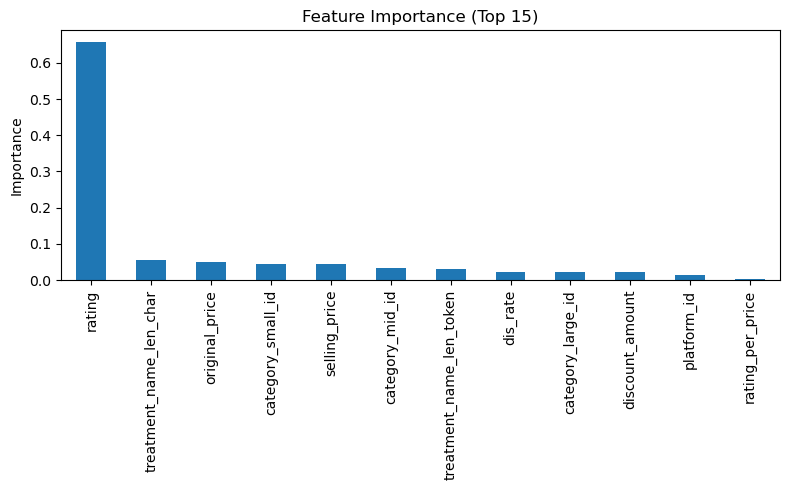

C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



=== 할인율 시뮬레이션 결과 (예시 1개 시술) ===
   dis_rate  pred_log_review  pred_review  selling_price
0         0              0.0          0.0        40000.0
1        10              0.0          0.0        36000.0
2        20              0.0          0.0        32000.0
3        30              0.0          0.0        28000.0
4        40              0.0          0.0        24000.0
5        50              0.0          0.0        20000.0


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


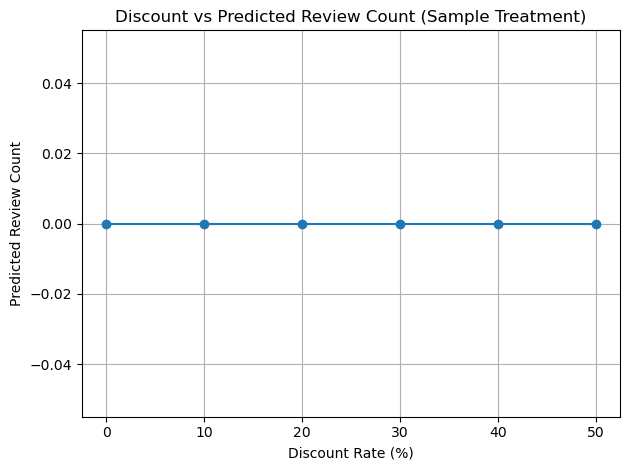

In [2]:
# ==============================
# 0. 라이브러리 임포트
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt


# ==============================
# 1. 데이터 불러오기
# ==============================
# 전처리된 파일 기준
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

print("데이터 shape:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())
print(df.head(3))


# ==============================
# 2. 피처 / 타깃 분리
# ==============================
# 타깃: log_review_count (리뷰수 로그 변환)
target_col = "log_review_count"

# 피처: 플랫폼/카테고리 ID + 가격/할인 + 평점 + 제목 길이
feature_cols = [
    "platform_id",
    "category_large_id", "category_mid_id", "category_small_id",
    "original_price", "selling_price", "discount_amount", "dis_rate",
    "rating", "rating_per_price",
    "treatment_name_len_char", "treatment_name_len_token",
]

X = df[feature_cols].fillna(0)
y = df[target_col].fillna(0)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# ==============================
# 3. Train/Test 분할 + 스케일링
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)

# 스케일링 (트리 모델에 필수는 아니지만, 나중에 다른 모델 쓸 때도 재사용 가능)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ==============================
# 4. RandomForest로 리뷰 수(log) 회귀
# ==============================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)


# ==============================
# 5. R² / RMSE로 성능 체크
# ==============================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 예측
y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

# 점수
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)
train_rmse = rmse(y_train, y_train_pred)
test_rmse  = rmse(y_test, y_test_pred)

print("\n=== 성능 평가 결과 ===")
print(f"Train R²   : {train_r2:.4f}")
print(f"Test  R²   : {test_r2:.4f}")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test  RMSE : {test_rmse:.4f}")


# ==============================
# 6. Feature importance로 뭐가 중요한지 확인
# ==============================
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("\n=== Feature Importance (상위 15개) ===")
print(feat_importance.head(15))

plt.figure(figsize=(8, 5))
feat_importance.head(15).plot(kind="bar")
plt.title("Feature Importance (Top 15)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# ==============================
# 7. 할인율 시뮬레이션 함수
#    - “이 시술은 할인율을 몇 % 줄 때 리뷰가 많이 달릴까?”
# ==============================
def simulate_discount_effect(row, discount_rates=[0, 10, 20, 30, 40, 50]):
    """
    row: df에서 한 행 (시술 1개, df.iloc[i])
    discount_rates: 테스트할 할인율 리스트 (% 단위)
    """
    sim_results = []

    for dr in discount_rates:
        tmp = row.copy()

        # 1) 할인율 변경
        tmp["dis_rate"] = dr

        # 2) 할인율에 맞춰 판매가/할인액 재계산
        tmp["selling_price"] = tmp["original_price"] * (1 - dr / 100)
        tmp["discount_amount"] = tmp["original_price"] - tmp["selling_price"]

        # 3) 가격 대비 평점 재계산
        tmp["rating_per_price"] = tmp["rating"] / (tmp["selling_price"] + 1e-6)

        # 4) 피처만 추출해서 모델에 넣기
        x_sim = tmp[feature_cols].values.reshape(1, -1)
        x_sim_scaled = scaler.transform(x_sim)

        log_pred = model.predict(x_sim_scaled)[0]
        review_pred = np.expm1(log_pred)  # log1p 역변환 → 예측 리뷰 수

        sim_results.append({
            "dis_rate": dr,
            "pred_log_review": log_pred,
            "pred_review": review_pred,
            "selling_price": tmp["selling_price"]
        })

    return pd.DataFrame(sim_results)


# ==============================
# 8. 시뮬레이션 예시: 첫 번째 시술에 대해 할인율 0~50% 테스트
# ==============================
sample_row = df.iloc[0]   # 0번째 시술
sim_df = simulate_discount_effect(
    sample_row,
    discount_rates=[0, 10, 20, 30, 40, 50]
)

print("\n=== 할인율 시뮬레이션 결과 (예시 1개 시술) ===")
print(sim_df)

plt.figure()
plt.plot(sim_df["dis_rate"], sim_df["pred_review"], marker="o")
plt.xlabel("Discount Rate (%)")
plt.ylabel("Predicted Review Count")
plt.title("Discount vs Predicted Review Count (Sample Treatment)")
plt.grid(True)
plt.tight_layout()
plt.show()

데이터 shape: (15714, 22)

사용 피처 목록 (별점 제거 후):
['platform_id', 'category_large_id', 'category_mid_id', 'category_small_id', 'original_price', 'selling_price', 'discount_amount', 'dis_rate', 'treatment_name_len_char', 'treatment_name_len_token']

=== 성능 결과 (별점 제거 모델) ===
Train R²   : 0.8906
Test  R²   : 0.2344
Train RMSE : 0.6724
Test  RMSE : 1.7491

=== Feature Importance ===
treatment_name_len_char     0.165048
selling_price               0.150329
original_price              0.148076
category_small_id           0.142308
treatment_name_len_token    0.086523
platform_id                 0.066665
discount_amount             0.065168
dis_rate                    0.063866
category_mid_id             0.061892
category_large_id           0.050125
dtype: float64


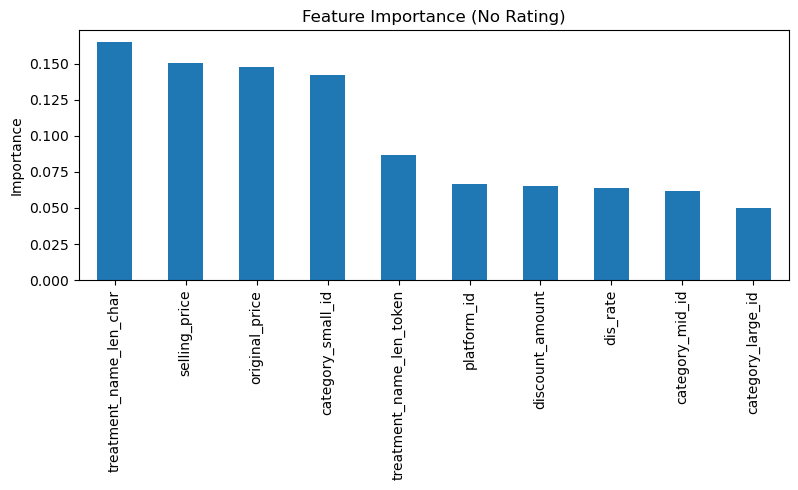


=== 할인율 시뮬레이션 (별점 제거 모델) ===
   dis_rate  pred_log_review  pred_review  selling_price
0         0         2.003478     6.414799        89000.0
1        10         2.527382    11.520680        80100.0
2        20         2.587132    12.291602        71200.0
3        30         2.407011    10.100731        62300.0
4        40         2.368869     9.685302        53400.0
5        50         2.404650    10.074550        44500.0


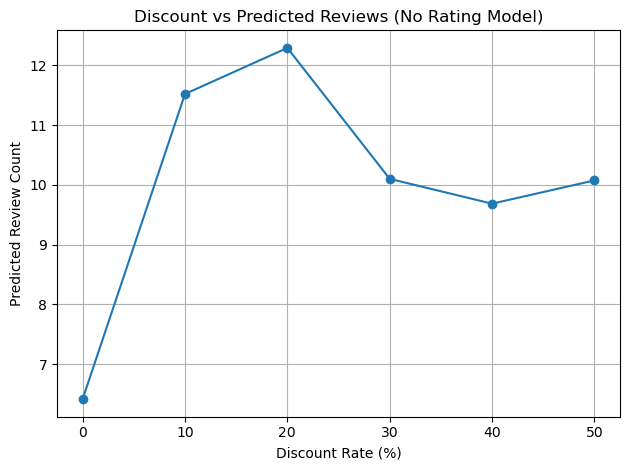

In [4]:
# ==============================
# 0. 라이브러리
# 가격·할인·카테고리·제목 길이만으로 리뷰 수를 예측하는 모델
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt


# ==============================
# 1. 데이터 불러오기
# ==============================
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

print("데이터 shape:", df.shape)


# ==============================
# 2. ⭐ 별점 관련 피처 제거
# ==============================
# 기존 feature_cols에서 rating / rating_per_price 제거
feature_cols = [
    "platform_id",
    "category_large_id", "category_mid_id", "category_small_id",
    "original_price", "selling_price", "discount_amount", "dis_rate",
    "treatment_name_len_char", "treatment_name_len_token",
]

target_col = "log_review_count"

X = df[feature_cols].fillna(0)
y = df[target_col].fillna(0)

print("\n사용 피처 목록 (별점 제거 후):")
print(feature_cols)


# ==============================
# 3. Train/Test Split + Scaling
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ==============================
# 4. RandomForest 학습
# ==============================
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)


# ==============================
# 5. 성능 평가 (R² / RMSE)
# ==============================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

y_train_pred = model.predict(X_train_scaled)
y_test_pred  = model.predict(X_test_scaled)

print("\n=== 성능 결과 (별점 제거 모델) ===")
print(f"Train R²   : {r2_score(y_train, y_train_pred):.4f}")
print(f"Test  R²   : {r2_score(y_test, y_test_pred):.4f}")
print(f"Train RMSE : {rmse(y_train, y_train_pred):.4f}")
print(f"Test  RMSE : {rmse(y_test, y_test_pred):.4f}")


# ==============================
# 6. Feature Importance
# ==============================
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("\n=== Feature Importance ===")
print(feat_importance)

plt.figure(figsize=(8,5))
feat_importance.plot(kind="bar")
plt.title("Feature Importance (No Rating)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# ==============================
# 7. 할인율 시뮬레이션 (별점 없이)
# ==============================
def simulate_discount_effect(row, discount_rates=[0, 10, 20, 30, 40, 50]):
    sim_results = []

    for dr in discount_rates:
        tmp = row.copy()

        tmp["dis_rate"] = dr
        tmp["selling_price"] = tmp["original_price"] * (1 - dr / 100)
        tmp["discount_amount"] = tmp["original_price"] - tmp["selling_price"]

        # ⭐ rating 관련 피처 없음 → feature_cols만 사용
        x_sim = pd.DataFrame([tmp[feature_cols]], columns=feature_cols)
        x_sim_scaled = scaler.transform(x_sim)

        log_pred = model.predict(x_sim_scaled)[0]
        review_pred = np.expm1(log_pred)

        sim_results.append({
            "dis_rate": dr,
            "pred_log_review": log_pred,
            "pred_review": review_pred,
            "selling_price": tmp["selling_price"]
        })

    return pd.DataFrame(sim_results)


# ==============================
# 8. 시뮬레이션 예시 (리뷰 있는 시술로 테스트 권장)
# ==============================
sample_row = df[df["review_count"] > 10].iloc[0]
sim_df = simulate_discount_effect(sample_row)

print("\n=== 할인율 시뮬레이션 (별점 제거 모델) ===")
print(sim_df)

plt.figure()
plt.plot(sim_df["dis_rate"], sim_df["pred_review"], marker="o")
plt.xlabel("Discount Rate (%)")
plt.ylabel("Predicted Review Count")
plt.title("Discount vs Predicted Reviews (No Rating Model)")
plt.grid(True)
plt.tight_layout()
plt.show()


데이터 shape: (15714, 22)
   treatment_id platform  platform_id       treatment_name  \
0          2031    yeoti            3        365 sy- 제모(여)   
1          2103    yeoti            3  365 sy- 탄력,색소,모공,홍조   
2          2187    yeoti            3            아기레이저 4만샷   

   treatment_name_len_char  treatment_name_len_token category_large  \
0                       13                         3             제모   
1                       19                         3             피부   
2                        9                         2             피부   

   category_large_id category_mid  category_mid_id  ... original_price  \
0                  6         얼굴제모               32  ...          40000   
1                  9        피부레이저               60  ...          99000   
2                  9        피부레이저               60  ...          89000   

   selling_price  discount_amount  dis_rate  rating  rating_per_price  \
0          33000             7000        18     0.0           0.00000   


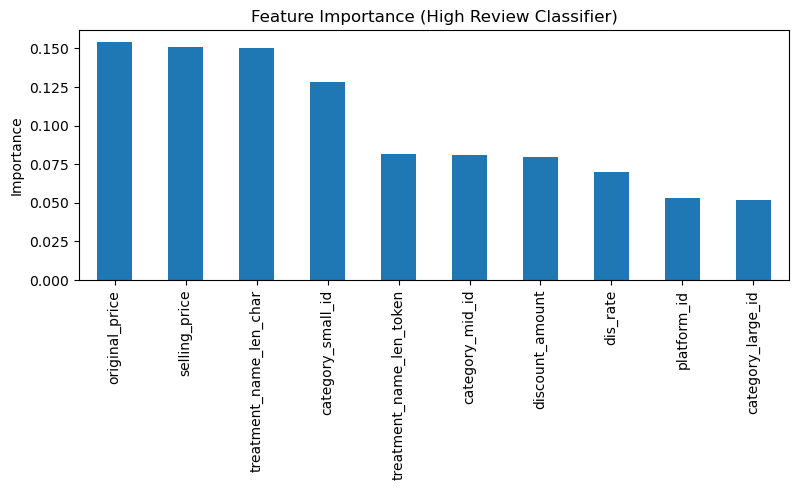


시뮬레이션 대상 시술 정보:
treatment_name    아기레이저 4만샷
review_count           21.0
original_price        89000
selling_price         82000
dis_rate                  8
Name: 2, dtype: object

=== 할인율별 '상위20% 시술'이 될 확률 시뮬레이션 ===
   dis_rate  selling_price  prob_high_review
0         0        89000.0          0.093333
1        10        80100.0          0.090000
2        20        71200.0          0.123333
3        30        62300.0          0.150000
4        40        53400.0          0.130000
5        50        44500.0          0.216667


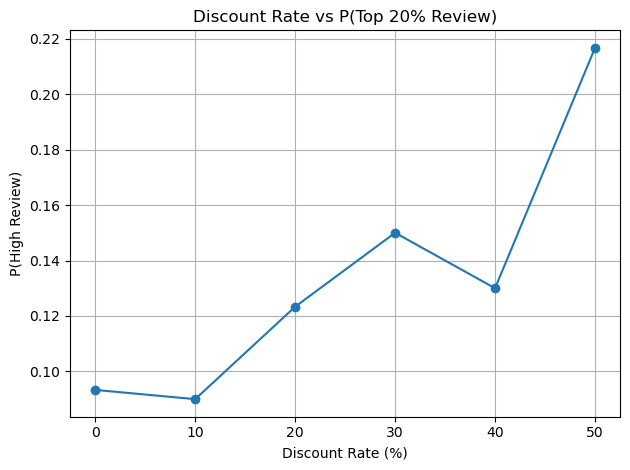

In [5]:
# =========================================
# 0. 라이브러리
# 가격/할인/카테고리/제목 길이만 가지고 “잘 나가는 시술인지(상위 20%)” 분류하는 버전
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


# =========================================
# 1. 데이터 불러오기
# =========================================
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

print("데이터 shape:", df.shape)
print(df.head(3))


# =========================================
# 2. 타깃(label): 리뷰 상위 20% 여부 (high_review_flag)
#    - review_count 기준 상위 20% 를 1, 나머지는 0
# =========================================
review_threshold = df["review_count"].quantile(0.8)  # 상위 20% 컷
print("\n리뷰 상위 20% 기준 review_count threshold:", review_threshold)

df["high_review_flag"] = (df["review_count"] >= review_threshold).astype(int)

print("\nhigh_review_flag 분포:")
print(df["high_review_flag"].value_counts(normalize=True) * 100)


# =========================================
# 3. 피처 선택 (별점 제외 버전)
# =========================================
feature_cols = [
    "platform_id",
    "category_large_id", "category_mid_id", "category_small_id",
    "original_price", "selling_price", "discount_amount", "dis_rate",
    "treatment_name_len_char", "treatment_name_len_token",
]

target_col = "high_review_flag"

X = df[feature_cols].fillna(0)
y = df[target_col]

print("\n사용 피처 컬럼:")
print(feature_cols)
print("X shape:", X.shape, "y shape:", y.shape)


# =========================================
# 4. Train/Test 분할 + 스케일링
#    - stratify=y 로 클래스 비율 유지
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)


# =========================================
# 5. 분류 모델 학습 (RandomForestClassifier)
#    - class_weight='balanced' 로 불균형 보정
# =========================================
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

clf.fit(X_train_scaled, y_train)


# =========================================
# 6. 성능 평가 (Accuracy, Precision, Recall, F1, ROC-AUC)
# =========================================
# 기본 threshold 0.5 기준
y_train_pred = clf.predict(X_train_scaled)
y_test_pred  = clf.predict(X_test_scaled)

# 양성 클래스(=상위20%) 확률
y_train_proba = clf.predict_proba(X_train_scaled)[:, 1]
y_test_proba  = clf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Train 성능 ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1       :", f1_score(y_train, y_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_proba))

print("\n=== Test 성능 ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1       :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_proba))

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_test_pred))

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


# =========================================
# 7. Feature Importance 시각화
# =========================================
importances = clf.feature_importances_
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("\n=== Feature Importance (분류 모델) ===")
print(feat_importance)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind="bar")
plt.title("Feature Importance (High Review Classifier)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# =========================================
# 8. 할인율 시뮬레이션:
#    - 특정 시술에 대해 할인율을 바꿔가며
#      "상위 20%에 들어갈 확률"을 계산
# =========================================
def simulate_discount_prob(row, discount_rates=[0, 10, 20, 30, 40, 50]):
    """
    row: df에서 한 행 (시술 1개)
    discount_rates: 테스트할 할인율 리스트 (%)
    """
    sim_results = []

    for dr in discount_rates:
        tmp = row.copy()

        # 할인율 변경
        tmp["dis_rate"] = dr
        tmp["selling_price"] = tmp["original_price"] * (1 - dr / 100)
        tmp["discount_amount"] = tmp["original_price"] - tmp["selling_price"]

        # 모델 입력용 피처
        x_sim = pd.DataFrame([tmp[feature_cols]], columns=feature_cols)
        x_sim_scaled = scaler.transform(x_sim)

        prob_high = clf.predict_proba(x_sim_scaled)[0, 1]  # 상위20%가 될 확률

        sim_results.append({
            "dis_rate": dr,
            "selling_price": tmp["selling_price"],
            "prob_high_review": prob_high
        })

    return pd.DataFrame(sim_results)


# =========================================
# 9. 시뮬레이션 예시
#    - 리뷰가 어느 정도 있는 시술 하나 골라서 테스트
# =========================================
sample_row = df[df["review_count"] > 10].iloc[0]
print("\n시뮬레이션 대상 시술 정보:")
print(sample_row[["treatment_name", "review_count", "original_price", "selling_price", "dis_rate"]])

sim_df = simulate_discount_prob(sample_row, discount_rates=[0, 10, 20, 30, 40, 50])

print("\n=== 할인율별 '상위20% 시술'이 될 확률 시뮬레이션 ===")
print(sim_df)

plt.figure()
plt.plot(sim_df["dis_rate"], sim_df["prob_high_review"], marker="o")
plt.xlabel("Discount Rate (%)")
plt.ylabel("P(High Review)")
plt.title("Discount Rate vs P(Top 20% Review)")
plt.grid(True)
plt.tight_layout()
plt.show()

데이터 shape: (15714, 22)
   treatment_id platform  platform_id       treatment_name  \
0          2031    yeoti            3        365 sy- 제모(여)   
1          2103    yeoti            3  365 sy- 탄력,색소,모공,홍조   
2          2187    yeoti            3            아기레이저 4만샷   

   treatment_name_len_char  treatment_name_len_token category_large  \
0                       13                         3             제모   
1                       19                         3             피부   
2                        9                         2             피부   

   category_large_id category_mid  category_mid_id  ... original_price  \
0                  6         얼굴제모               32  ...          40000   
1                  9        피부레이저               60  ...          99000   
2                  9        피부레이저               60  ...          89000   

   selling_price  discount_amount  dis_rate  rating  rating_per_price  \
0          33000             7000        18     0.0           0.00000   


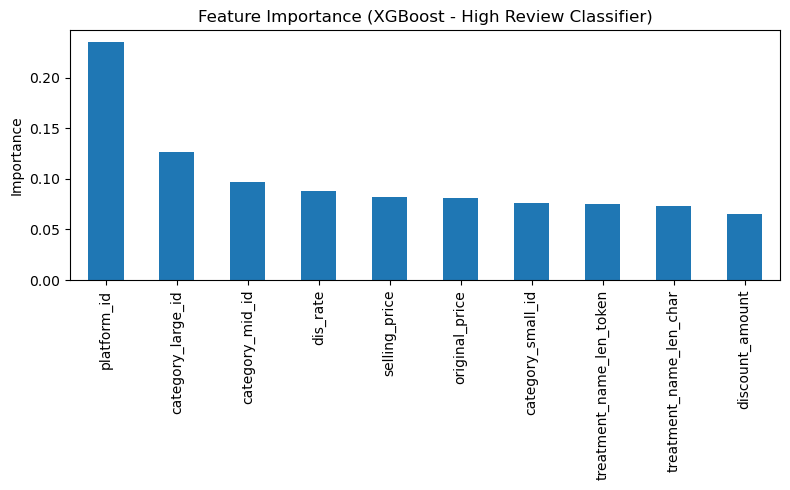


시뮬레이션 대상 시술 정보:
treatment_name    아기레이저 4만샷
review_count           21.0
original_price        89000
selling_price         82000
dis_rate                  8
Name: 2, dtype: object

=== 할인율별 '상위20% 시술'이 될 확률 시뮬레이션 (XGBoost) ===
   dis_rate  selling_price  prob_high_review
0         0        89000.0          0.311864
1        10        80100.0          0.348692
2        20        71200.0          0.354094
3        30        62300.0          0.385799
4        40        53400.0          0.376652
5        50        44500.0          0.445335


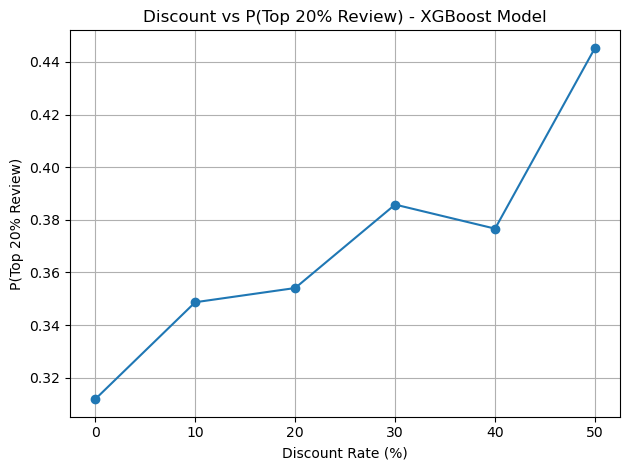

In [8]:
# =========================================
# 0. 라이브러리
# XGBoost 분류 모델 전체 코드
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# XGBoost
from xgboost import XGBClassifier


# =========================================
# 1. 데이터 불러오기
# =========================================
df = pd.read_excel("final_treatment_master_preprocessed_for_ml.xlsx")

print("데이터 shape:", df.shape)
print(df.head(3))


# =========================================
# 2. 타깃(label): 리뷰 상위 20% 여부 (high_review_flag)
# =========================================
review_threshold = df["review_count"].quantile(0.8)  # 상위 20% 컷
print("\n리뷰 상위 20% 기준 review_count threshold:", review_threshold)

df["high_review_flag"] = (df["review_count"] >= review_threshold).astype(int)

print("\nhigh_review_flag 분포 (%):")
print(df["high_review_flag"].value_counts(normalize=True) * 100)


# =========================================
# 3. 피처 선택 (별점 제거 버전)
# =========================================
feature_cols = [
    "platform_id",
    "category_large_id", "category_mid_id", "category_small_id",
    "original_price", "selling_price", "discount_amount", "dis_rate",
    "treatment_name_len_char", "treatment_name_len_token",
]

target_col = "high_review_flag"

X = df[feature_cols].fillna(0)
y = df[target_col]

print("\n사용 피처 컬럼:")
print(feature_cols)
print("X shape:", X.shape, "y shape:", y.shape)


# =========================================
# 4. Train/Test 분할
#    - stratify=y 로 클래스 비율 유지
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Test  shape:", X_test.shape, y_test.shape)


# =========================================
# 5. 클래스 불균형 보정용 scale_pos_weight 계산
#    - neg/pos 비율
# =========================================
num_pos = y_train.sum()
num_neg = len(y_train) - num_pos
scale_pos_weight = num_neg / num_pos

print("\nPositive(1) 개수:", int(num_pos))
print("Negative(0) 개수:", int(num_neg))
print("scale_pos_weight:", scale_pos_weight)


# =========================================
# 6. XGBoost 모델 정의 & 학습
# =========================================
xgb_clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,  # 클래스 불균형 보정
    random_state=42,
    n_jobs=-1,
    tree_method="hist"  # 속도 개선용
)

xgb_clf.fit(X_train, y_train)


# =========================================
# 7. 성능 평가
# =========================================
# 기본 threshold = 0.5
y_train_pred = xgb_clf.predict(X_train)
y_test_pred  = xgb_clf.predict(X_test)

y_train_proba = xgb_clf.predict_proba(X_train)[:, 1]
y_test_proba  = xgb_clf.predict_proba(X_test)[:, 1]

print("\n=== Train 성능 (XGBoost) ===")
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1       :", f1_score(y_train, y_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, y_train_proba))

print("\n=== Test 성능 (XGBoost) ===")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1       :", f1_score(y_test, y_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_test_proba))

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_test_pred))

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_test_pred))


# =========================================
# 8. Feature Importance 시각화
# =========================================
importances = xgb_clf.feature_importances_
feat_importance = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

print("\n=== Feature Importance (XGBoost) ===")
print(feat_importance)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind="bar")
plt.title("Feature Importance (XGBoost - High Review Classifier)")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


# =========================================
# 9. 할인율별 '상위 20%가 될 확률' 시뮬레이션
# =========================================
def simulate_discount_prob_xgb(row, discount_rates=[0, 10, 20, 30, 40, 50]):
    """
    row: df에서 한 행 (시술 1개)
    discount_rates: 테스트할 할인율 리스트 (%)
    반환: 할인율별 상위 20%가 될 확률
    """
    sim_results = []

    for dr in discount_rates:
        tmp = row.copy()

        # 할인율 변경
        tmp["dis_rate"] = dr
        tmp["selling_price"] = tmp["original_price"] * (1 - dr / 100)
        tmp["discount_amount"] = tmp["original_price"] - tmp["selling_price"]

        # 피처만 추출
        x_sim = pd.DataFrame([tmp[feature_cols]], columns=feature_cols)

        prob_high = xgb_clf.predict_proba(x_sim)[0, 1]

        sim_results.append({
            "dis_rate": dr,
            "selling_price": tmp["selling_price"],
            "prob_high_review": prob_high
        })

    return pd.DataFrame(sim_results)


# =========================================
# 10. 시뮬레이션 예시
# =========================================
sample_row = df[df["review_count"] > 10].iloc[0]

print("\n시뮬레이션 대상 시술 정보:")
print(sample_row[["treatment_name", "review_count", "original_price", "selling_price", "dis_rate"]])

sim_df = simulate_discount_prob_xgb(sample_row, discount_rates=[0, 10, 20, 30, 40, 50])

print("\n=== 할인율별 '상위20% 시술'이 될 확률 시뮬레이션 (XGBoost) ===")
print(sim_df)

plt.figure()
plt.plot(sim_df["dis_rate"], sim_df["prob_high_review"], marker="o")
plt.xlabel("Discount Rate (%)")
plt.ylabel("P(Top 20% Review)")
plt.title("Discount vs P(Top 20% Review) - XGBoost Model")
plt.grid(True)
plt.tight_layout()
plt.show()